In [125]:
import numpy as np
import matplotlib.pyplot as plt

In [126]:
#КОНСТАНТЫ

a      = 6378137.0 
e2     = 6.6943799901413 * 10**(-3)
g_e    = 9.78030
beta_1 = 5.302 * 10**(-3)
beta_2 = 7 * 10**(-6)
d_g    = 14 * 10**(-5)
U      = 0.00007292115

In [127]:
#Все необходимые функции 
def R_E(phi):
    return a / np.sqrt(1 - e2 * np.sin(phi)**2)

def R_N(phi):
    return a * (1 - e2) / (1 - e2 * np.sin(phi)**2)**(3/2)

def gelmert(phi, h):
    return g_e * (1 + beta_1 * np.sin(phi)**2 - beta_2 * np.sin(2 * phi)**2 - 2 * h / a) - d_g

def hat(w):
    w1, w2, w3 = w
    return np.array([[0,  w3, -w2],
                     [-w3, 0,  w1],
                     [w2, -w1, 0]])

def L(psi, theta, gamma):
   def L_11(theta, psi):
       return np.cos(theta) * np.sin(psi)
   def L_12(theta, psi):
       return np.cos(theta) * np.cos(psi)
   def L_13(theta):
       return np.sin(theta)
   def L_21(psi, theta, gamma):
       return -np.sin(theta) * np.sin(psi) * np.cos(gamma) + np.cos(psi) * np.sin(gamma)
   def L_22(psi, theta, gamma):
       return  -np.sin(theta) * np.cos(psi) * np.cos(gamma) - np.sin(psi) * np.sin(gamma)
   def L_23(theta, gamma):
       return np.cos(theta) * np.cos(gamma)
   def L_31 (psi, theta, gamma):
       return np.sin(theta) * np.sin(psi) * np.sin(gamma) + np.cos(psi) * np.cos(gamma)
   def L_32(psi, theta, gamma):
       return np.sin(theta) * np.cos(psi) * np.sin(gamma) - np.sin(psi) * np.cos(gamma)
   def L_33(theta, gamma):
       return -np.cos(theta) * np.sin(gamma)
   
   return np.array([[L_11(theta, psi), L_12(theta, psi), L_13(theta)],
                    [L_21(psi, theta, gamma), L_22(psi, theta, gamma), L_23(theta, gamma)],
                    [L_31(psi, theta, gamma), L_32(psi, theta, gamma), L_33(theta, gamma)]])

def u_x(phi):
    return np.array([0, U * np.cos(phi), U * np.sin(phi)])

def Omega_x(phi, V, h):
    
    V1, V2 = V[0], V[1]
    
    RE = R_E(phi)
    RN = R_N(phi)

    return np.array ([-V2 / (RN + h), V1 / (RE + h), V1 * np.tan(phi) / (RE + h)])

def g_x(phi, h):
    return np.array([0.0, 0.0, -gelmert(phi, h)])

def phi_dot(V, phi, h):
    V2 = V[1]
    RN = R_N(phi)

    return V2/(RN + h)

def lamb_dot(V, phi, h):
    V1 = V[0]
    RE = R_E(phi)

    return V1 / ((RE + h) * np.cos(phi))

def h_dot(V):
    return V[2]

def V_dot(phi, psi, theta, gamma, fz, h, V):
    return (hat(Omega_x(phi, V, h)) + 2 * hat(u_x(phi))) @ V + g_x(phi, h) + L(psi, theta, gamma).T @ fz

In [128]:
#Чтение файлов 
imu   = np.loadtxt("imu.txt", skiprows = 1)
imu = imu[:-3]
t_imu = imu[:, 0]
f_z   = imu[:, 4:7]

trj = np.loadtxt("trj.txt", skiprows = 1)
trj = trj[:-3]

t_trj = trj[:, 0]

lat_trj     = np.deg2rad(trj[:, 1])
lon_trj     = np.deg2rad(trj[:, 2])

h_ref_trj   = trj[:, 3]

Ve_ref_trj  = trj[:, 4]
Vn_ref_trj  = trj[:, 5]
Vup_ref_trj = trj[:, 6]

psi_trj     = np.deg2rad(trj[:, 7])   
theta_trj   = np.deg2rad(trj[:, 8])  
gamma_trj   = np.deg2rad(trj[:, 9])

In [129]:
#Интерполяция на всяки случай, если временные сетки не совпадают 

lat   = np.interp(t_imu, t_trj, lat_trj)
lon   = np.interp(t_imu, t_trj, lon_trj)

h_ref = np.interp(t_imu, t_trj, h_ref_trj)

Ve_ref  = np.interp(t_imu, t_trj, Ve_ref_trj)
Vn_ref  = np.interp(t_imu, t_trj, Vn_ref_trj)
Vup_ref = np.interp(t_imu, t_trj, Vup_ref_trj)

psi   = np.interp(t_imu, t_trj, psi_trj)
theta = np.interp(t_imu, t_trj, theta_trj)
gamma = np.interp(t_imu, t_trj, gamma_trj)

In [130]:
n = len(t_imu)

phi  = np.zeros(n)
lamb = np.zeros(n)
h    = np.zeros(n)

V = np.zeros((n, 3))

In [131]:
#Начальные условия

phi[0]  = lat[0]
lamb[0] = lon[0] 

h[0] = h_ref[0]

V[0, :] = 0.0

In [132]:
#Решение методом Эйлера 

for i in range (n - 1):
  dt = t_imu[i + 1] - t_imu[i]

  phi[i + 1]  = phi[i] + dt * phi_dot(V[i, :], phi[i], h[i])
  lamb[i + 1] = lamb[i] + dt * lamb_dot(V[i, :], phi[i], h[i])
  h[i + 1]    = h[i] + dt * h_dot(V[i, :])

  V[i + 1] = V[i] + dt * V_dot(phi[i], psi[i], theta[i], gamma[i], f_z[i, :], h[i], V[i,:])

In [133]:
#Ошибки

dV = np.column_stack([V[:,0] - Ve_ref, 
                      V[:,1] - Vn_ref, 
                      V[:,2] - Vup_ref])


d_east   = (lamb - lon) * (R_E(phi) + h) * np.cos(phi)
d_north  = (phi - lat) * (R_N(phi) + h)
d_height = (h - h_ref)


errors = np.column_stack([
    t_imu,
    dV[:, 0], dV[:, 1], dV[:, 2],  
    d_east, d_north, d_height])

#запись ошибок в отдельный файл

np.savetxt(
    "errors.txt",
    errors,
    header = "t[s] dVe[m/s] dVn[m/s] dVup[m/s] dE[m] dN[m] dU[m]",
    fmt = "%.6f")


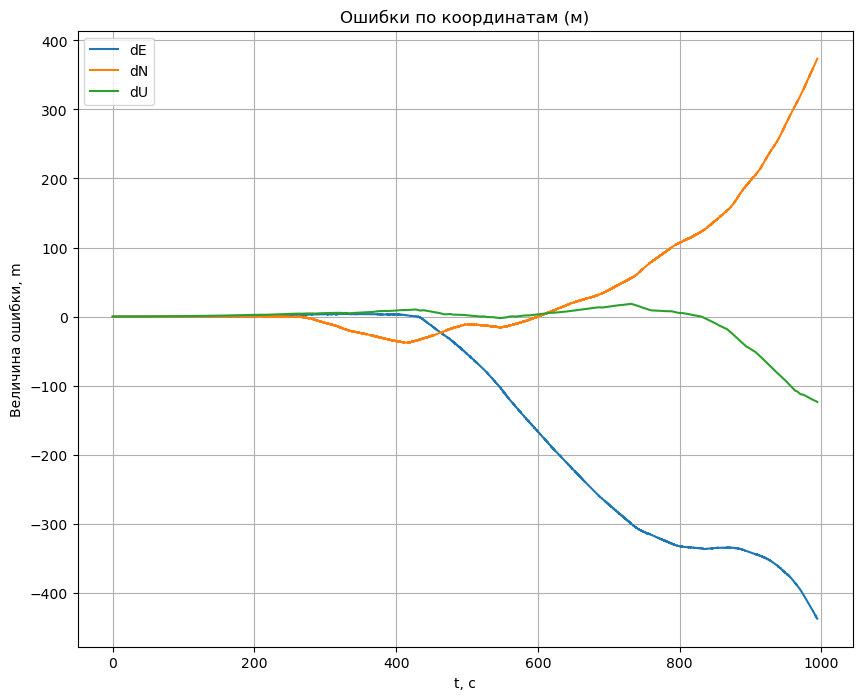

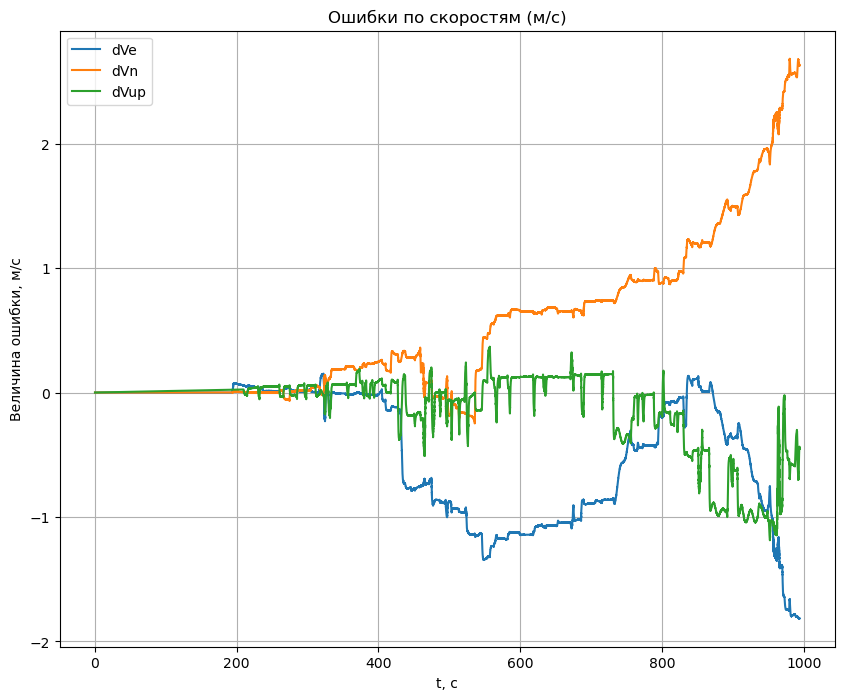

In [134]:

plt.figure(figsize = (10, 8))
plt.plot(t_imu, d_east, label = "dE")
plt.plot(t_imu, d_north, label = "dN")
plt.plot(t_imu, d_height, label = "dU")
plt.xlabel("t, с"); 
plt.ylabel("Величина ошибки, m")
plt.grid(True); 
plt.legend(); 
plt.title("Ошибки по координатам (м)")

plt.figure(figsize = (10, 8))
plt.plot(t_imu, dV[:,0], label = "dVe")
plt.plot(t_imu, dV[:,1], label = "dVn")
plt.plot(t_imu, dV[:,2], label = "dVup")
plt.xlabel("t, с"); 
plt.ylabel("Величина ошибки, м/с")
plt.grid(True); 
plt.legend(); 
plt.title("Ошибки по скоростям (м/с)")

plt.show()